In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%capture
!pip install -q imgaug albumentations==1.3.1 timm einops ftfy regex lmdb fvcore
!pip install -q "numpy<2" --force-reinstall

In [ ]:
import numpy, torch, torchvision
# print("numpy:", numpy.__version__)
# print("torch:", torch.__version__)
# print("torchvision:", torchvision.__version__)
print("CUDA:", torch.cuda.is_available())

CUDA: True


In [ ]:
%%capture
%cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/DeepfakeBench
!pip install jedi
!python -m pip install -U pip setuptools wheel
!pip install -r requirements.txt
!pip install -e .

In [ ]:
%%capture
%cd "/content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub"
!head -n -1 requirements.txt > requirements_no_flash.txt
!pip install -r requirements_no_flash.txt

In [3]:
import os, glob, json, random

TRAIN_DIR = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/training_data"
VAL_DIR   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/validation_data"
TEST_DIR  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/Datasets/publictest_data"

VAL_REF   = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/validation_reference/reference.txt"
TEST_REF  = "/content/drive/MyDrive/Capstone_Hripsime/Database/RDDC_Dataset/RDDC_References/publictest_reference/reference.txt"

STAGING = "/content/DiffusionForensics_Recons"
os.makedirs(STAGING, exist_ok=True)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff")

# ═══════════════════════════════════════════════════
# TRAINING — training_data_final
# ═══════════════════════════════════════════════════
train_items = []
for ext in IMG_EXTS:
    for p in glob.glob(os.path.join(TRAIN_DIR, f"*{ext}")):
        name = os.path.basename(p).lower()
        if "_real" in name:
            train_items.append({"path": p, "label": 0})
        elif "_fake" in name:
            train_items.append({"path": p, "label": 1})

random.seed(42)
random.shuffle(train_items)

n_real = sum(1 for x in train_items if x["label"] == 0)
n_fake = sum(1 for x in train_items if x["label"] == 1)
print(f"TRAIN: {len(train_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# VALIDATION — validation_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(VAL_REF) as f:
    val_labels = [int(line.strip()) for line in f if line.strip()]

val_images = sorted(glob.glob(os.path.join(VAL_DIR, "*.*")))
val_images = [p for p in val_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(val_images) == len(val_labels), \
    f"Mismatch: {len(val_images)} images vs {len(val_labels)} labels"

val_items = [{"path": p, "label": l} for p, l in zip(val_images, val_labels)]

n_real = sum(1 for x in val_items if x["label"] == 0)
n_fake = sum(1 for x in val_items if x["label"] == 1)
print(f"VAL:   {len(val_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# TEST — publictest_data_final + reference.txt
# ═══════════════════════════════════════════════════
with open(TEST_REF) as f:
    test_labels = [int(line.strip()) for line in f if line.strip()]

test_images = sorted(glob.glob(os.path.join(TEST_DIR, "*.*")))
test_images = [p for p in test_images if os.path.splitext(p)[1].lower() in IMG_EXTS]

assert len(test_images) == len(test_labels), \
    f"Mismatch: {len(test_images)} images vs {len(test_labels)} labels"

test_items = [{"path": p, "label": l} for p, l in zip(test_images, test_labels)]

n_real = sum(1 for x in test_items if x["label"] == 0)
n_fake = sum(1 for x in test_items if x["label"] == 1)
print(f"TEST:  {len(test_items)} images  (real={n_real}, fake={n_fake})")

# ═══════════════════════════════════════════════════
# SAVE JSONs
# ═══════════════════════════════════════════════════
for name, data in [("train", train_items), ("val", val_items), ("test", test_items)]:
    out = os.path.join(STAGING, f"{name}.json")
    with open(out, "w") as f:
        json.dump(data, f)
    print(f"\n✓ {name}.json → {len(data)} items → {out}")


TRAIN: 1000 images  (real=500, fake=500)
VAL:   100 images  (real=50, fake=50)
TEST:  1000 images  (real=500, fake=500)

✓ train.json → 1000 items → /content/DiffusionForensics_Recons/train.json

✓ val.json → 100 items → /content/DiffusionForensics_Recons/val.json

✓ test.json → 1000 items → /content/DiffusionForensics_Recons/test.json


In [ ]:
# %cd /content/drive/MyDrive/Capstone_Hripsime/Frameworks/ForensicHub

# !PYTHONPATH=$PWD MASTER_ADDR=127.0.0.1 MASTER_PORT=29601 \
# python -m ForensicHub.training_scripts.test \
# --config "ForensicHub/statics/crossdataset_image/recce_test.yaml"

2026-04-26 10:25:12.107259: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777199112.174057   11411 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777199112.201128   11411 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777199112.258369   11411 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777199112.258427   11411 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777199112.258437   11411 computation_placer.cc:177] computation placer alr

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt

preds  = np.load("/content/preds.npy")
labels = np.load("/content/labels.npy")
y_pred = (preds >= 0.5).astype(int)

print(f"AUC: {roc_auc_score(labels, preds):.4f}")
print(f"F1 : {f1_score(labels, y_pred):.4f}")
# print(f"Acc: {(y_pred == labels).mean():.4f}")

cm = confusion_matrix(labels, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["real","fake"]).plot(cmap="Blues")
plt.title("RECCE — Public Test (1000 imgs)")
plt.show()

Parsed scores: (1000,)
Parsed labels: (1000,)
Unique labels: [0, 1]

RECCE public-test metrics from extracted text
P:    0.5146
R:    0.4940
F1:   0.5041
Acc:  0.5140
AUC:  0.5251
------------------------------------------------------------
TP: 247
TN: 267
FP: 233
FN: 253
Correct: 514/1000
Wrong:   486/1000
Copied RECCE train log to: /content/drive/MyDrive/Capstone_Hripsime/submission/logs/recce_train/log.txt

Saved RECCE artifacts:
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/recce/preds.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/recce/labels.npy
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/recce/recce_test_inference_results.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/test_outputs/recce/metadata.json
 - /content/drive/MyDrive/Capstone_Hripsime/submission/results/figures/recce_test_confusion_matrix_reproduced.jpg


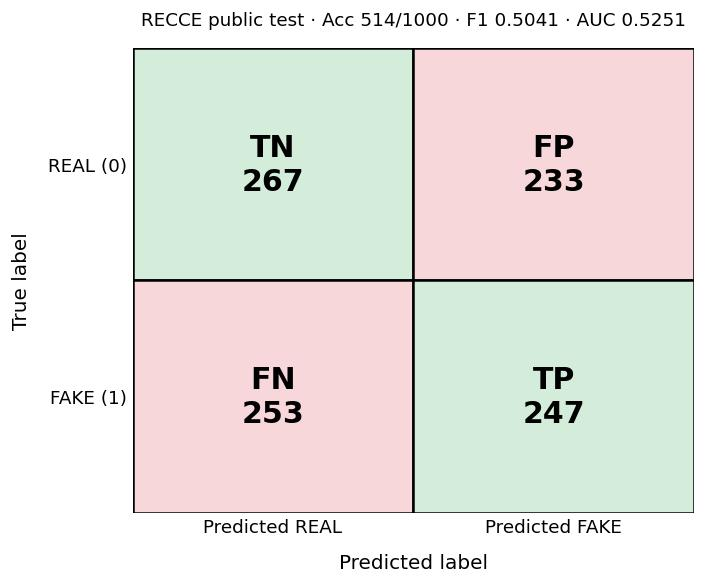

In [6]:
# ============================================================
# Extract RECCE pred/label arrays from printed text output
# Save preds.npy / labels.npy to Drive for one-command reproduction
# ============================================================

%matplotlib inline

import re
import os
import json
import shutil
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score,
)
from IPython.display import Image, display

# ============================================================
# PASTE THE FULL RECCE OUTPUT TEXT BETWEEN THE TRIPLE QUOTES
# ============================================================

RECCE_OUTPUT_TEXT = r"""
pred: [0.46729466 0.50534016 0.4636363  0.49267295 0.46572006 0.4520632
 0.4595505  0.42202407 0.48878512 0.48866448 0.50884086 0.524944
 0.5003448  0.52404064 0.48505715 0.4635811  0.4478952  0.4101807
 0.4793833  0.4481344  0.5227216  0.5008186  0.5330894  0.51075625
 0.5476917  0.54077214 0.5766979  0.5084062  0.47045994 0.48888442
 0.4955026  0.5036131  0.5154918  0.51956105 0.5125414  0.4695468
 0.49219164 0.48559746 0.5117052  0.5592893  0.5103171  0.5184485
 0.49837682 0.47180983 0.58188903 0.52233297 0.5444498  0.5729769
 0.5119261  0.49400997 0.52571386 0.5146267  0.49257404 0.5242329
 0.4995275  0.49867594 0.42076886 0.52997434 0.55432534 0.46706167
 0.47154927 0.523033   0.47818485 0.5386204  0.5605666  0.42346543
 0.4793248  0.571808   0.4997868  0.5674763  0.4545854  0.485454
 0.5373189  0.54631543 0.541969   0.495507   0.46363565 0.48490697
 0.40614226 0.40754494 0.44889885 0.3982928  0.4783595  0.46133834
 0.4792389  0.47643933 0.4757942  0.4980212  0.522477   0.49352697
 0.44026226 0.43965685 0.46353266 0.5007748  0.57992744 0.43462515
 0.52988136 0.37580773 0.49309048 0.5197425  0.5461587  0.43916932
 0.51486087 0.4689949  0.47184223 0.5077261  0.5287114  0.53629154
 0.55040723 0.51352876 0.490537   0.5212221  0.49140307 0.48870292
 0.4558705  0.52548087 0.48353213 0.45473978 0.4580306  0.44120178
 0.43853062 0.5064556  0.47834152 0.5068064  0.4012365  0.42359778
 0.51308066 0.51712614 0.48213938 0.4291865  0.48545986 0.4944451
 0.52198607 0.58710647 0.4818097  0.5035274  0.44855598 0.46544245
 0.6055315  0.5096167  0.46676454 0.5284021  0.43121976 0.49210083
 0.55468607 0.47641847 0.598834   0.4500992  0.48150504 0.47101057
 0.4534754  0.5680404  0.4822038  0.55096704 0.48723245 0.46148044
 0.5240985  0.48143274 0.4241176  0.47185424 0.44729403 0.6048048
 0.480469   0.47863916 0.4555932  0.47739562 0.5408912  0.5547514
 0.5022154  0.44593608 0.58065826 0.577895   0.45979908 0.5182358
 0.4664809  0.5186709  0.5345801  0.38962036 0.49600428 0.492287
 0.5022522  0.49342903 0.47670427 0.50150913 0.48614055 0.4876553
 0.54563093 0.52673215 0.5619574  0.48915082 0.5051465  0.47203016
 0.42836434 0.52317965 0.51069236 0.4249466  0.5356455  0.5690589
 0.46008626 0.4731575  0.4429045  0.40405968 0.47338447 0.55475414
 0.46139395 0.47856686 0.5550338  0.47569832 0.5066684  0.45076877
 0.5290587  0.4759833  0.4953462  0.50394565 0.5163786  0.548478
 0.48174286 0.52304524 0.508649   0.516239   0.559857   0.5305262
 0.4909995  0.5063381  0.4806344  0.5406563  0.48879802 0.45457765
 0.5110876  0.4074909  0.5196558  0.48402596 0.52053696 0.5164998
 0.5185676  0.5325878  0.48845565 0.5135503  0.5496326  0.52380866
 0.5048547  0.497814   0.52157575 0.4704059  0.41725397 0.5094473
 0.5349199  0.511038   0.45763212 0.51027876 0.39271128 0.44381383
 0.49753028 0.4507584  0.44350347 0.41508093 0.49353027 0.52727
 0.46393612 0.4835584  0.53339005 0.5669053  0.53018594 0.47093964
 0.5171835  0.5134242  0.5286534  0.53504694 0.5445723  0.54694486
 0.52874917 0.4829234  0.47614434 0.5058689  0.51585156 0.42190537
 0.53749585 0.5173644  0.5051946  0.4729485  0.5068677  0.4710943
 0.48436105 0.50456446 0.45012587 0.47946    0.56763023 0.4906496
 0.5224548  0.43656015 0.49817607 0.4962984  0.49608347 0.52183354
 0.48845226 0.45725477 0.5131257  0.52371913 0.52244896 0.46751317
 0.4591618  0.44069523 0.51218593 0.42290822 0.4513837  0.5203419
 0.47019276 0.53155434 0.55479944 0.52932763 0.4985223  0.4638132
 0.4522072  0.5094996  0.48560292 0.5435148  0.5488792  0.5067639
 0.50844556 0.49340025 0.46039328 0.6050081  0.538895   0.524153
 0.52025014 0.4876744  0.54777086 0.48111376 0.5544123  0.4657342
 0.47106385 0.5087819  0.5019866  0.58324176 0.51622784 0.5926183
 0.5237797  0.5775386  0.48687908 0.56415045 0.5026639  0.45390105
 0.51261294 0.55846584 0.41745222 0.48049754 0.5001601  0.50100195
 0.4722421  0.4635567  0.5624246  0.51133466 0.49221486 0.5007932
 0.5475806  0.49837416 0.39942867 0.52509755 0.4315442  0.48296365
 0.50264275 0.523393   0.506391   0.48785454 0.5124341  0.48143825
 0.5087273  0.50669515 0.5062338  0.46438068 0.50437194 0.4802237
 0.44573534 0.45961243 0.45968652 0.5170467  0.51567954 0.4909352
 0.38307706 0.49466985 0.49302098 0.45881703 0.5745469  0.3923601
 0.521074   0.4632789  0.49324787 0.5417523  0.5205678  0.4983636
 0.51581967 0.5479031  0.47127414 0.5452495  0.49640706 0.5484013
 0.5118571  0.5337545  0.49433827 0.53717417 0.47139904 0.50165695
 0.50344634 0.5074524  0.48032704 0.45906052 0.45852146 0.5412826
 0.4890815  0.47330868 0.4919559  0.5678837  0.5344035  0.46604544
 0.4084439  0.5221493  0.451864   0.43235347 0.57849956 0.49526408
 0.5093063  0.471747   0.47653538 0.52103466 0.3944447  0.47370037
 0.56137884 0.5297116  0.48128456 0.48967123 0.547284   0.4526464
 0.4040491  0.5372211  0.5070658  0.41429305 0.48661485 0.49035156
 0.48948485 0.484635   0.45676664 0.46800846 0.43727097 0.5373437
 0.3975777  0.52527404 0.47423628 0.51167446 0.49227664 0.53583485
 0.53928465 0.46735004 0.50182784 0.53982675 0.46871597 0.48478028
 0.5811811  0.4239703  0.5430954  0.55876374 0.5133387  0.54440653
 0.4825948  0.54225886 0.49406147 0.5123165  0.5163066  0.5643606
 0.5139591  0.56199855 0.4753971  0.53231716 0.48188967 0.49552134
 0.5643979  0.58529073 0.5133992  0.5335934  0.5399821  0.47630626
 0.49662602 0.5491183  0.47382095 0.48972172 0.4782036  0.5211095
 0.43912557 0.5022899  0.5157021  0.48610958 0.53466135 0.5232561
 0.43581855 0.5207621  0.5523846  0.50980675 0.46472037 0.42388612
 0.48730373 0.3919668  0.38941598 0.5554148  0.45604733 0.48191008
 0.5364171  0.4926239  0.45125288 0.51283234 0.5076365  0.48664886
 0.4647335  0.5191165  0.48895818 0.51244825 0.5031209  0.43682614
 0.4947604  0.5008839  0.4895072  0.54975486 0.515065   0.43459338
 0.4892134  0.49252936 0.492281   0.46526334 0.48995864 0.4768381
 0.5051021  0.496866   0.43516126 0.414121   0.42575124 0.48492834
 0.55771846 0.487622   0.5012853  0.42567155 0.49532655 0.49330425
 0.53682554 0.41281292 0.535016   0.521224   0.45659065 0.4975771
 0.57567    0.5042002  0.5239174  0.45001012 0.5051527  0.5176728
 0.49433511 0.46172655 0.5310182  0.5136864  0.5326901  0.5443725
 0.5500838  0.49662137 0.52340436 0.5024914  0.5025375  0.6099983
 0.39709052 0.4392654  0.5619218  0.4577188  0.46470305 0.5277942
 0.4770195  0.5262963  0.5215502  0.4969214  0.41616836 0.48220283
 0.5087156  0.49767336 0.4788743  0.52026826 0.54704326 0.521173
 0.5052116  0.4606285  0.5330639  0.43808028 0.47354752 0.5418817
 0.55729413 0.46186602 0.47965056 0.47584727 0.4634554  0.5570013
 0.4798173  0.54135495 0.5531344  0.43481383 0.4393833  0.5752603
 0.4279994  0.4089204  0.471577   0.5246949  0.46572474 0.55326265
 0.47467837 0.46978682 0.5665838  0.48665628 0.41256112 0.48672473
 0.52727693 0.5617093  0.5049933  0.41106594 0.5082367  0.38639897
 0.5038063  0.53570914 0.44827092 0.47661912 0.5193904  0.5484036
 0.48257622 0.4854557  0.4848361  0.46631315 0.48629457 0.51287705
 0.4693333  0.47241908 0.5327781  0.55629456 0.5459375  0.5206837
 0.4657023  0.46548748 0.50266576 0.5017896  0.45342302 0.4837777
 0.46866924 0.5579679  0.4771678  0.4506382  0.4864818  0.5508553
 0.46952236 0.46477157 0.5525328  0.43519115 0.57745767 0.4788496
 0.42778206 0.54018456 0.5074292  0.4752498  0.546158   0.45513287
 0.53339815 0.5872064  0.5133204  0.5181944  0.46190727 0.4813807
 0.5393481  0.47771552 0.46070904 0.5151332  0.4747393  0.53945714
 0.4552037  0.51845014 0.5218893  0.46595183 0.4585011  0.52578205
 0.53450906 0.5343315  0.53075624 0.50662893 0.42679515 0.47172615
 0.5628925  0.5498089  0.44599295 0.4644297  0.50303096 0.53206843
 0.48307982 0.42283624 0.46097952 0.4913423  0.43335298 0.5114606
 0.4488501  0.5257584  0.54369754 0.40783948 0.5077804  0.51791805
 0.5963383  0.46286058 0.5117062  0.52370334 0.49048787 0.46101138
 0.4985506  0.4578935  0.48661348 0.5454107  0.5640635  0.5378701
 0.52426946 0.53314555 0.49900576 0.5074491  0.43022785 0.4730925
 0.3880297  0.5570865  0.5639725  0.48444352 0.5605341  0.48379064
 0.5237208  0.5364449  0.4903329  0.51634896 0.4789218  0.5482073
 0.46942976 0.5523263  0.4907384  0.5176362  0.45212787 0.45442608
 0.40996236 0.5016336  0.37567958 0.5527627  0.5285113  0.47642788
 0.39725527 0.4781813  0.43615454 0.50784564 0.5074798  0.48801547
 0.48540592 0.49109855 0.5508612  0.50776345 0.54425055 0.54727584
 0.49806562 0.4477518  0.52377087 0.44091925 0.448514   0.4155022
 0.46303523 0.5430326  0.47069743 0.5686866  0.46790102 0.45671406
 0.49365464 0.45821965 0.52528787 0.4818126  0.4499875  0.52000606
 0.42923555 0.5756594  0.58499426 0.4837574  0.5087592  0.4592381
 0.47052002 0.50652987 0.48770106 0.57023215 0.5481833  0.5095226
 0.51036376 0.46412048 0.55803674 0.5405454  0.48553506 0.55225766
 0.50511533 0.54443395 0.46154043 0.45258206 0.49206233 0.50711393
 0.53015107 0.5397191  0.5259554  0.4973062  0.4860078  0.5189836
 0.5403862  0.4389271  0.5411245  0.54480565 0.4976919  0.4984696
 0.58489496 0.51813245 0.54013187 0.42785692 0.4952914  0.4359059
 0.46121582 0.50462687 0.48631153 0.48847115 0.46192437 0.5451841
 0.44268322 0.49691144 0.4854504  0.49445528 0.47122437 0.46883276
 0.49652928 0.5355786  0.49731782 0.44395915 0.4739844  0.44095212
 0.48477617 0.43892998 0.48084268 0.512687   0.4004127  0.49412757
 0.5401406  0.4892562  0.52074516 0.41207916 0.47018063 0.54124886
 0.45163044 0.52080435 0.55198485 0.4969415  0.5606231  0.55605966
 0.504819   0.40101027 0.4650247  0.49545112 0.5070355  0.5178206
 0.47756115 0.47940642 0.44860184 0.52596855 0.42735574 0.50939095
 0.48565724 0.4640815  0.5277194  0.4700903  0.5079547  0.5425228
 0.48490518 0.5204304  0.5440699  0.5526469  0.4981174  0.47515476
 0.47975847 0.50845176 0.55969125 0.49064258 0.5647194  0.501653
 0.46811572 0.49262574 0.49759907 0.526963   0.46430576 0.4759836
 0.3621361  0.39586687 0.4721735  0.53444296 0.4630078  0.4887817
 0.5209397  0.48768222 0.43482593 0.47325122 0.5293015  0.51777744
 0.5038404  0.45930868 0.5092776  0.49621797 0.5416252  0.492605
 0.5704399  0.61648124 0.52460814 0.5735192  0.50548667 0.46688858
 0.45690823 0.46075928 0.50712365 0.5261021  0.49025536 0.4881141
 0.51841223 0.43960163 0.4355654  0.48521158 0.50106007 0.46813357
 0.5282894  0.50865847 0.49936464 0.47446278 0.5322893  0.44618642
 0.44989    0.48873797 0.46492884 0.49112016 0.59244543 0.5156767
 0.5456544  0.46538773 0.56568307 0.47758353 0.5589896  0.4832899
 0.47543514 0.5476322  0.51003736 0.50346303 0.50115067 0.5465851
 0.5091725  0.46047255 0.41156936 0.5385194  0.46740615 0.5062025
 0.6382298  0.4278151  0.47706226 0.48989356 0.46016338 0.48084274
 0.5387034  0.57126236 0.5070766  0.5363569  0.48633838 0.48442295
 0.50158125 0.44366595 0.47728598 0.4866529  0.5491503  0.5812424
 0.48694074 0.51890707 0.5361051  0.50250536 0.4414965  0.54869837
 0.4930996  0.53999704 0.48998687 0.46583977 0.5269009  0.57711023
 0.5226256  0.55254346 0.5632136  0.49156424 0.54233044 0.5371809
 0.43323714 0.52381945 0.49839336 0.5361491  0.52261513 0.56048334
 0.52516365 0.5863741  0.5273737  0.58879656]
video_auc: 0.5250760000000001
label: [0 0 1 0 1 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0 1 0 1 1 0 0 0 1
 1 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 0 1
 1 1 0 1 1 1 1 0 0 0 0 0 1 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 1 0
 0 1 1 1 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1 0 0 1 0 1 1 1 0 1
 0 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 0 1 1 0 1
 1 0 1 0 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 0 1 1 0 1 1
 0 1 1 0 0 0 1 0 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 0
 1 0 1 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 1 0
 0 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 1 1 0 1 0 0
 0 0 0 0 1 0 0 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0
 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 1
 0 1 1 1 1 0 0 1 1 0 1 1 0 0 0 0 1 0 1 0 1 1 1 0 1 1 0 0 1 1 0 1 1 0 0 1 1
 1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 1 1 1 1 1 1 0 0 0 0 0 0
 1 0 0 0 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 0 0 0 1 1 1 0 1 0 1 1 1 0 1 1
 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 1 1 0 1 1 0 1 0 1 1 1 1 0 1
 0 0 0 1 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 0 0 1 0 1 1 1 1 0 1 0 0
 1 0 0 1 1 0 1 1 0 1 1 0 1 0 1 1 0 1 1 0 1 0 0 0 1 0 0 1 1 0 1 1 0 1 1 0 1
 0 0 1 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 0 1 0 1 1
 0 0 0 0 1 1 0 1 1 1 1 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 1 1 0 0 0 1 1 0
 0 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0
 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 1 1 1 1 0 1 0 1 0 0 1 0 0 1
 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 0 0 0 1 0 1 0 0 1 1 0 0 0 1 1 1 0 1 1 0
 1 1 0 0 1 0 0 0 1 0 1 1 0 1 0 1 1 1 0 0 1 1 1 0 0 0 1 0 1 1 1 1 1 0 0 1 1
 0 0 0 0 1 1 1 1 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 1 1 1 1 0 1 0
 0 0 0 1 0 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1 1
 1 1 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 0 1 0 0 0 0
 0 0 0 1 0 0 1 1 1 1 0 1 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 0 1 1 0 1 1
 1]"""

# ============================================================
# Parse arrays
# ============================================================

def parse_array_from_output(text, key, stop_key=None):
    if stop_key is None:
        pattern = rf"{key}:\s*\[([\s\S]*?)\]"
    else:
        pattern = rf"{key}:\s*\[([\s\S]*?)\]\s*{stop_key}"

    match = re.search(pattern, text)
    if match is None:
        raise ValueError(f"Could not find array for '{key}' in pasted output.")

    body = match.group(1).replace("\n", " ")
    arr = np.fromstring(body, sep=" ")

    if arr.size == 0:
        raise ValueError(f"Array for '{key}' was found but parsed as empty.")

    return arr

scores = parse_array_from_output(RECCE_OUTPUT_TEXT, "pred", stop_key="video_auc").astype(float)
labels = parse_array_from_output(RECCE_OUTPUT_TEXT, "label").astype(int)

scores = scores.reshape(-1)
labels = labels.reshape(-1)

print("Parsed scores:", scores.shape)
print("Parsed labels:", labels.shape)
print("Unique labels:", sorted(set(labels.tolist())))

if len(scores) != len(labels):
    raise ValueError(f"Length mismatch: scores={len(scores)}, labels={len(labels)}")

# ============================================================
# Paths
# ============================================================

SUBMISSION_ROOT = Path("/content/drive/MyDrive/Capstone_Hripsime/submission")

RECCE_OUT = SUBMISSION_ROOT / "test_outputs" / "recce"
RECCE_OUT.mkdir(parents=True, exist_ok=True)

RECCE_LOG_OUT = SUBMISSION_ROOT / "logs" / "recce_train"
RECCE_LOG_OUT.mkdir(parents=True, exist_ok=True)

FIG_DIR = SUBMISSION_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

BASE = "/content/drive/MyDrive/Capstone_Hripsime/Frameworks"
CHECKPOINT_DIR = f"{BASE}/ForensicHub/log/recce_train"
LOG_PATH = f"{CHECKPOINT_DIR}/log.txt"

THRESHOLD = 0.5

# ============================================================
# Metrics
# ============================================================

pred_labels = (scores >= THRESHOLD).astype(int)

precision = precision_score(labels, pred_labels, zero_division=0)
recall = recall_score(labels, pred_labels, zero_division=0)
f1 = f1_score(labels, pred_labels, zero_division=0)
acc = accuracy_score(labels, pred_labels)
auc = roc_auc_score(labels, scores)

cm = confusion_matrix(labels, pred_labels, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

total = TP + TN + FP + FN
correct = TP + TN
wrong = FP + FN

print("\n" + "=" * 60)
print("RECCE public-test metrics from extracted text")
print("=" * 60)
print(f"P:    {precision:.4f}")
print(f"R:    {recall:.4f}")
print(f"F1:   {f1:.4f}")
print(f"Acc:  {acc:.4f}")
print(f"AUC:  {auc:.4f}")
print("-" * 60)
print(f"TP: {TP}")
print(f"TN: {TN}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"Correct: {correct}/{total}")
print(f"Wrong:   {wrong}/{total}")
print("=" * 60)

# ============================================================
# Save permanent artifacts
# ============================================================

np.save(RECCE_OUT / "preds.npy", scores)
np.save(RECCE_OUT / "labels.npy", labels)

results = []
for i, (label, score) in enumerate(zip(labels, scores)):
    pred = int(score >= THRESHOLD)
    results.append({
        "index": int(i),
        "true_label": int(label),
        "pred": int(pred),
        "score": float(score),
        "correct": bool(pred == int(label)),
    })

with open(RECCE_OUT / "recce_test_inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

metadata = {
    "model": "RECCE",
    "threshold": THRESHOLD,
    "checkpoint_dir": CHECKPOINT_DIR,
    "log_path": LOG_PATH,
    "source": "Recovered from printed notebook output containing pred and label arrays",
    "metrics": {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(acc),
        "auc": float(auc),
    },
    "confusion_matrix": {
        "TP": int(TP),
        "TN": int(TN),
        "FP": int(FP),
        "FN": int(FN),
    },
    "num_items": int(len(labels)),
}

with open(RECCE_OUT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

if os.path.exists(LOG_PATH):
    shutil.copy2(LOG_PATH, RECCE_LOG_OUT / "log.txt")
    print("Copied RECCE train log to:", RECCE_LOG_OUT / "log.txt")
else:
    print("WARNING: RECCE train log not found:", LOG_PATH)

# ============================================================
# Plot confusion matrix
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")

cell_labels = [["TN", "FP"], ["FN", "TP"]]
cell_values = [[TN, FP], [FN, TP]]
cell_colors = [
    ["#d4edda", "#f8d7da"],
    ["#f8d7da", "#d4edda"],
]

for i in range(2):
    for j in range(2):
        ax.add_patch(
            plt.Rectangle(
                (j, 1 - i),
                1,
                1,
                facecolor=cell_colors[i][j],
                edgecolor="black",
                linewidth=1.5,
            )
        )
        ax.text(
            j + 0.5,
            1 - i + 0.5,
            f"{cell_labels[i][j]}\n{cell_values[i][j]}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black",
        )

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_yticks([1.5, 0.5])

ax.set_xticklabels(["Predicted REAL", "Predicted FAKE"], fontsize=11)
ax.set_yticklabels(["REAL (0)", "FAKE (1)"], fontsize=11)

ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("True label", fontsize=12, labelpad=10)
ax.tick_params(length=0)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    f"RECCE public test · Acc {correct}/{total} · F1 {f1:.4f} · AUC {auc:.4f}",
    fontsize=11,
    pad=14,
)

plt.tight_layout()

fig_path = FIG_DIR / "recce_test_confusion_matrix_reproduced.jpg"
plt.savefig(fig_path, dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.close(fig)

print("\nSaved RECCE artifacts:")
print(" -", RECCE_OUT / "preds.npy")
print(" -", RECCE_OUT / "labels.npy")
print(" -", RECCE_OUT / "recce_test_inference_results.json")
print(" -", RECCE_OUT / "metadata.json")
print(" -", fig_path)

display(Image(filename=str(fig_path)))

In [ ]:
import nbformat
NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Recce Test.ipynb"
nb = nbformat.read(NOTEBOOK_PATH, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

nbformat.write(nb, NOTEBOOK_PATH)

In [ ]:
!pip install nbconvert -q

NOTEBOOK_PATH = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Recce Test.ipynb"
OUTPUT_DIR    = "/content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks"

!jupyter nbconvert \
    --to html \
    --embed-images \
    --output-dir "{OUTPUT_DIR}" \
    "{NOTEBOOK_PATH}"

print("Done — check your Drive for the .html file")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/Recce Test.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 371715 bytes to /content/drive/MyDrive/Capstone_Hripsime/Code Notebooks/HTML Notebooks/Recce Test.html
Done — check your Drive for the .html file
